# N4 — Multiples Construction

Builds the three valuation multiples used as validation targets throughout the pipeline.
Kept strictly separate from peer inputs — no leakage possible.

| Multiple | Formula | Column |
|----------|---------|--------|
| EV / Sales | ln(EV / sale) | `ln_v2s` |
| EV / Assets | ln(EV / at) | `ln_v2a` |
| Market Cap / SEQ | ln(mktcap / seq) | `ln_m2b` |

**Timing:** EV measured at fiscal year-end t (price × shares at `prcc_f` date).
No t+1 shift needed since we use fiscal year-end market data already embedded in Compustat.

**Output fed into:** N9 (evaluation — MdAPE computation)


In [10]:
# Cell 1 — imports & config
import sys; sys.path.insert(0, '..')
from config import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Config loaded.")
print(f"  PANEL_CLEAN : {PANEL_CLEAN}")
print(f"  MULTIPLES   : {MULTIPLES}")
print(f"  WINSOR      : {WINSOR_BOUNDS}")


Config loaded.
  PANEL_CLEAN : /work/Repo/notebooks/../data/processed/panel_clean.parquet
  MULTIPLES   : /work/Repo/notebooks/../data/processed/multiples.parquet
  WINSOR      : (0.01, 0.99)


In [11]:
# Cell 2 — declare I/O
INPUTS  = [PANEL_CLEAN]
OUTPUTS = [MULTIPLES]
# PURPOSE : Construct EV/Sales, EV/Assets, MktCap/SEQ multiples — validation targets
# RUNTIME : ~2 min
# DEPENDS : panel_clean.parquet (N1)


## 1. Load Panel

In [12]:
# Cell 3 — load panel_clean (only columns needed for multiples)
COLS_NEEDED = ['gvkey', 'tic', 'fyear', 'ff49_num', 'ff49_abbr', 'industry',
               'prcc_f', 'csho', 'at', 'sale', 'seq', 'dltt', 'dlc', 'che',
               'ebitda']

df = pd.read_parquet(PANEL_CLEAN, columns=COLS_NEEDED)
print(f"Loaded: {df.shape[0]:,} rows")
print(f"Years : {sorted(df['fyear'].unique())}")
print(f"Firms : {df['gvkey'].nunique():,} unique GVKEYs")


Loaded: 20,883 rows
Years : [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Firms : 5,700 unique GVKEYs


## 2. Construct Multiples

All three multiples are already computed in N1 as `ln_v2s`, `ln_v2a`, `ln_m2b`.
Here we reconstruct them cleanly from raw inputs, winsorise, and add the
unlogged versions for interpretability and robustness checks.


In [13]:
# Cell 4 — recompute EV and raw multiples from scratch (clean attribution)
df['market_cap'] = df['csho'] * df['prcc_f']
df['ev']         = (df['market_cap']
                    + df['dltt'].fillna(0)
                    + df['dlc'].fillna(0)
                    - df['che'].fillna(0))

# Raw (unlogged) multiples
df['ev_sales']       = df['ev']         / df['sale']
df['ev_assets']      = df['ev']         / df['at']
df['market_cap_seq'] = df['market_cap'] / df['seq']

# EV/EBITDA — robustness only, positive EBITDA firms
df['ev_ebitda'] = np.where(df['ebitda'] > 0, df['ev'] / df['ebitda'], np.nan)

print("Raw multiples computed.")
print(f"  ev_sales       — non-null: {df['ev_sales'].notna().sum():,}")
print(f"  ev_assets      — non-null: {df['ev_assets'].notna().sum():,}")
print(f"  market_cap_seq — non-null: {df['market_cap_seq'].notna().sum():,}")
print(f"  ev_ebitda      — non-null: {df['ev_ebitda'].notna().sum():,} "
      f"(positive EBITDA only)")


Raw multiples computed.
  ev_sales       — non-null: 20,883
  ev_assets      — non-null: 20,883
  market_cap_seq — non-null: 20,883
  ev_ebitda      — non-null: 15,899 (positive EBITDA only)


In [14]:
# Cell 5 — pre-winsorisation distribution check
print("Pre-winsorisation summary (raw multiples):")
for col in ['ev_sales', 'ev_assets', 'market_cap_seq', 'ev_ebitda']:
    s = df[col].dropna()
    print(f"  {col:<20} n={len(s):,}  "
          f"p1={s.quantile(0.01):.2f}  median={s.median():.2f}  "
          f"p99={s.quantile(0.99):.2f}  max={s.max():.1f}")


Pre-winsorisation summary (raw multiples):
  ev_sales             n=20,883  p1=0.16  median=2.61  p99=570.91  max=186757.9
  ev_assets            n=20,883  p1=0.02  median=1.02  p99=13.90  max=13312.1
  market_cap_seq       n=20,883  p1=0.32  median=2.08  p99=74.05  max=33476.1
  ev_ebitda            n=15,899  p1=0.86  median=10.67  p99=311.75  max=118509.3


## 3. Winsorise Multiples

Winsorisation applied **per fyear cross-section** at `WINSOR_BOUNDS = (0.01, 0.99)`.
Applied to multiples only — feature winsorisation was handled separately in N2.


In [15]:
# Cell 6 — winsorise multiples per fyear
MULTIPLE_COLS = ['ev_sales', 'ev_assets', 'market_cap_seq', 'ev_ebitda']
lo, hi = WINSOR_BOUNDS

for yr in YEARS:
    mask = df['fyear'] == yr
    for col in MULTIPLE_COLS:
        lo_val = df.loc[mask, col].quantile(lo)
        hi_val = df.loc[mask, col].quantile(hi)
        df.loc[mask, col] = df.loc[mask, col].clip(lower=lo_val, upper=hi_val)

print("Winsorisation complete.")
print("\nPost-winsorisation summary:")
for col in MULTIPLE_COLS:
    s = df[col].dropna()
    print(f"  {col:<20} n={len(s):,}  "
          f"p1={s.quantile(0.01):.2f}  median={s.median():.2f}  "
          f"p99={s.quantile(0.99):.2f}  max={s.max():.1f}")


Winsorisation complete.

Post-winsorisation summary:
  ev_sales             n=20,883  p1=0.18  median=2.61  p99=330.25  max=1335.7
  ev_assets            n=20,883  p1=0.03  median=1.02  p99=12.18  max=18.1
  market_cap_seq       n=20,883  p1=0.34  median=2.08  p99=61.58  max=89.6
  ev_ebitda            n=15,899  p1=1.04  median=10.67  p99=251.01  max=441.3


## 4. Log-Transform

In [16]:
# Cell 7 — log-transform (require positive values)
# Drop any remaining non-positive after winsorisation (safety net)
for col, log_col in [('ev_sales',       'ln_v2s'),
                     ('ev_assets',       'ln_v2a'),
                     ('market_cap_seq',  'ln_m2b'),
                     ('ev_ebitda',       'ln_ev_ebitda')]:
    df[log_col] = np.where(df[col] > 0, np.log(df[col]), np.nan)

print("Log-transformed multiples:")
for col in ['ln_v2s', 'ln_v2a', 'ln_m2b', 'ln_ev_ebitda']:
    s = df[col].dropna()
    print(f"  {col:<16} non-null={len(s):,}  "
          f"mean={s.mean():.3f}  std={s.std():.3f}  "
          f"min={s.min():.2f}  max={s.max():.2f}")


Log-transformed multiples:
  ln_v2s           non-null=20,883  mean=1.084  std=1.393  min=-1.98  max=7.20
  ln_v2a           non-null=20,883  mean=-0.055  std=1.187  min=-3.95  max=2.90
  ln_m2b           non-null=20,883  mean=0.888  std=1.035  min=-1.21  max=4.49
  ln_ev_ebitda     non-null=15,899  mean=2.419  std=0.963  min=-0.52  max=6.09


## 5. Distribution Plots

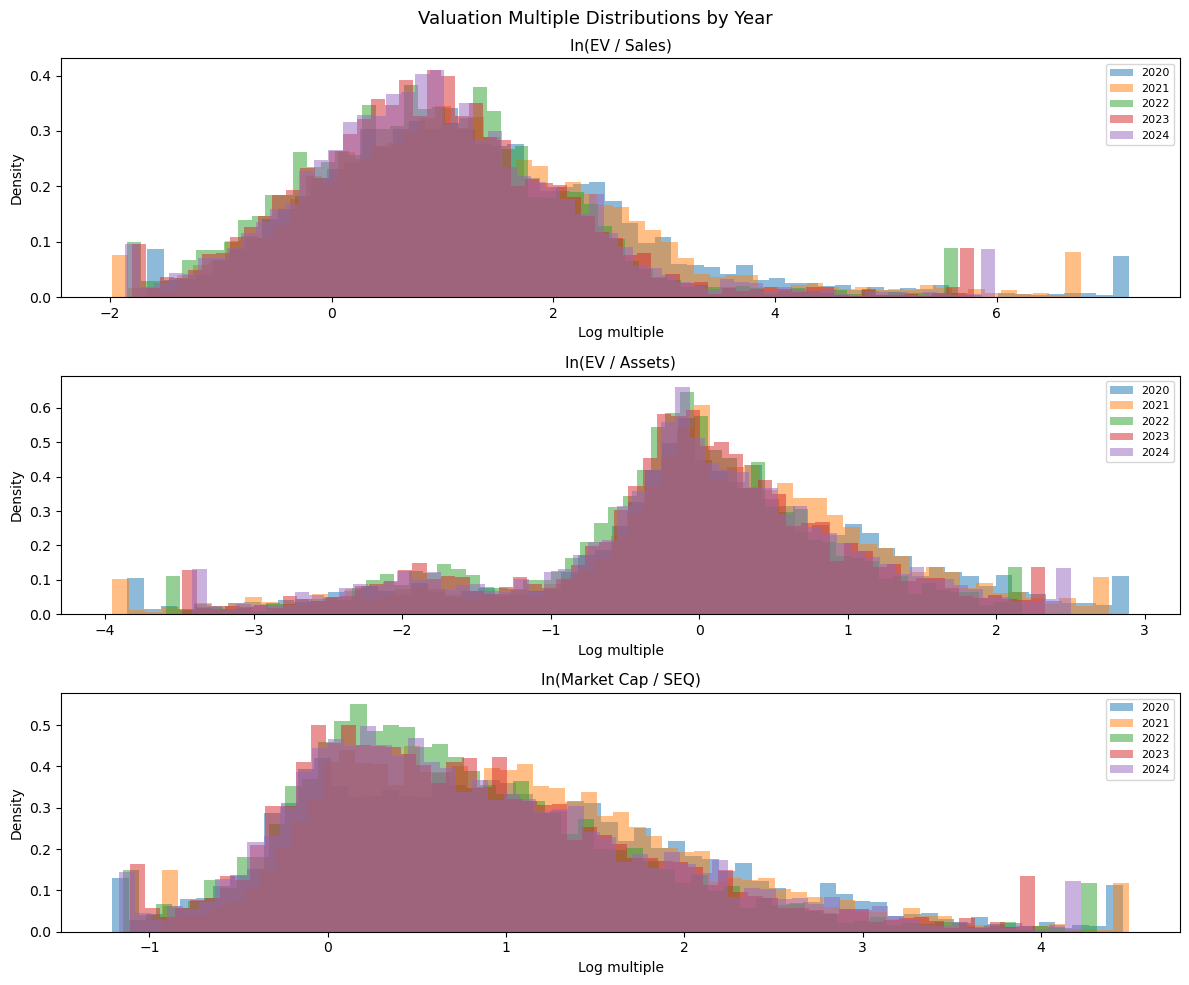

Saved: /work/Repo/notebooks/../figures/n4_multiples_distributions.pdf


In [17]:
# Cell 8 — distribution of log multiples by year
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

for ax, (col, label) in zip(axes, [
    ('ln_v2s', 'ln(EV / Sales)'),
    ('ln_v2a', 'ln(EV / Assets)'),
    ('ln_m2b', 'ln(Market Cap / SEQ)'),
]):
    for yr in YEARS:
        data = df[df['fyear'] == yr][col].dropna()
        ax.hist(data, bins=60, alpha=0.5, label=str(yr), density=True)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Log multiple')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle("Valuation Multiple Distributions by Year", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / "n4_multiples_distributions.pdf", dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES / 'n4_multiples_distributions.pdf'}")


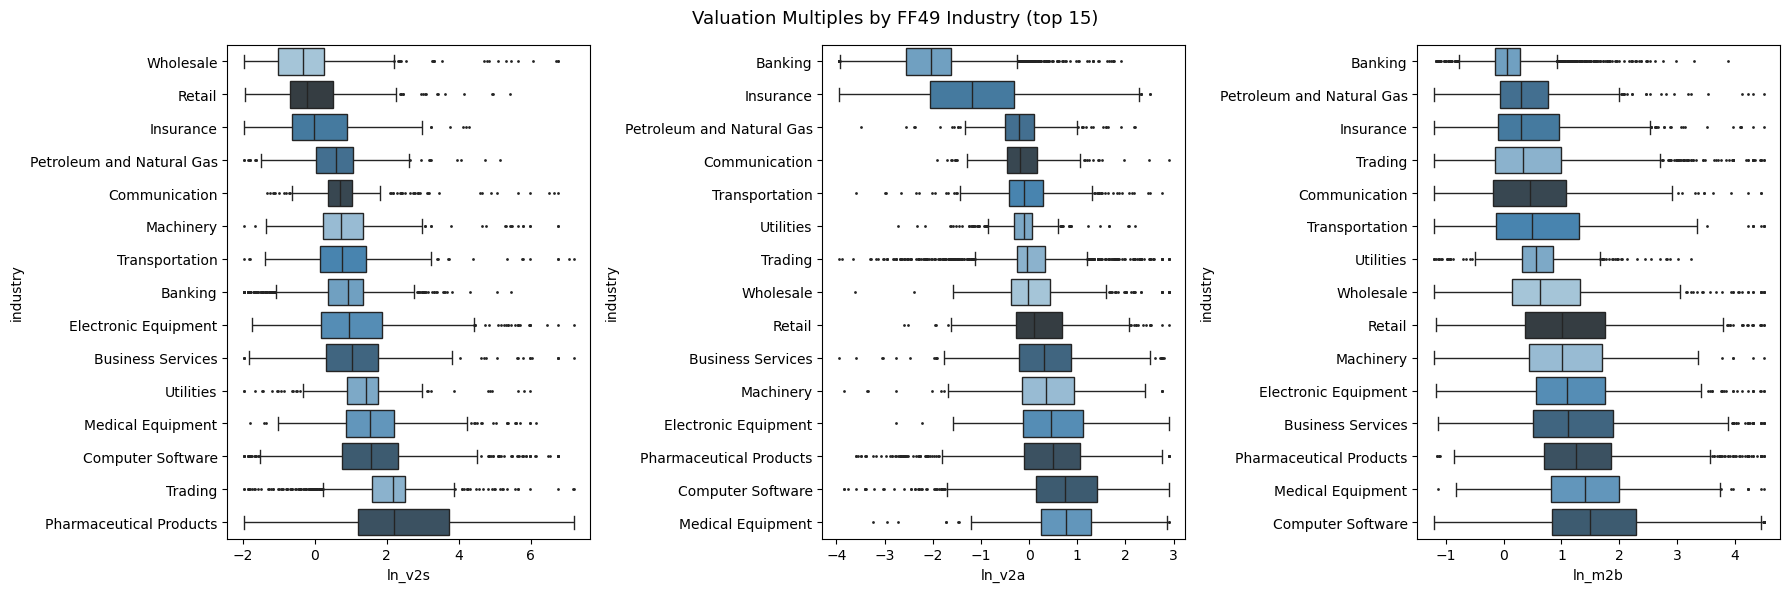

Saved: /work/Repo/notebooks/../figures/n4_multiples_by_industry.pdf


In [22]:
# Cell 9 — multiples by FF49 sector (top 15 industries by firm count)
top_industries = (df.groupby('industry')['gvkey']
                    .count()
                    .sort_values(ascending=False)
                    .head(15)
                    .index.tolist())

df_top = df[df['industry'].isin(top_industries)].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col, label in zip(axes,
    ['ln_v2s', 'ln_v2a', 'ln_m2b'],
    ['ln(EV/Sales)', 'ln(EV/Assets)', 'ln(MktCap/SEQ)']):

    order = (df_top.groupby('industry')[col]
                   .median()
                   .sort_values()
                   .index.tolist())

    sns.boxplot(data=df_top, y='industry', x=col, order=order,
            ax=ax, hue='industry', palette='Blues_d', 
            fliersize=1, legend=False)

plt.suptitle("Valuation Multiples by FF49 Industry (top 15)", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / "n4_multiples_by_industry.pdf", dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES / 'n4_multiples_by_industry.pdf'}")


## 6. Longitudinal Trends

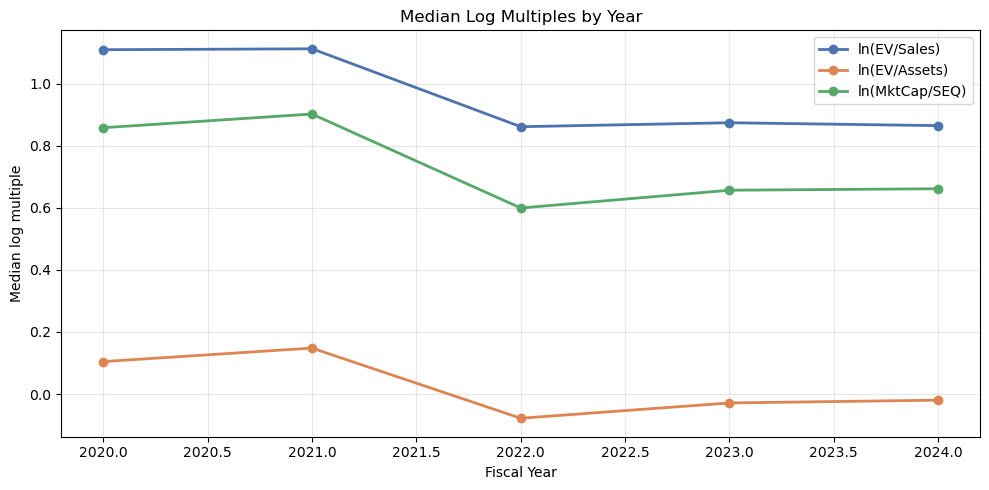

Saved: /work/Repo/notebooks/../figures/n4_multiples_longitudinal.pdf

Median multiples by year:
 fyear   ln_v2s    ln_v2a   ln_m2b
  2020 1.109548  0.104625 0.858186
  2021 1.112434  0.148218 0.902287
  2022 0.861463 -0.077928 0.599553
  2023 0.874214 -0.028651 0.656807
  2024 0.864896 -0.019645 0.661511


In [19]:
# Cell 10 — median multiples by year (longitudinal stability check)
yearly = (df.groupby('fyear')[['ln_v2s', 'ln_v2a', 'ln_m2b']]
            .median()
            .reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
for col, label, color in [
    ('ln_v2s', 'ln(EV/Sales)',    '#4C72B0'),
    ('ln_v2a', 'ln(EV/Assets)',   '#DD8452'),
    ('ln_m2b', 'ln(MktCap/SEQ)', '#55A868'),
]:
    ax.plot(yearly['fyear'], yearly[col], marker='o', label=label,
            color=color, linewidth=2)

ax.set_title("Median Log Multiples by Year", fontsize=12)
ax.set_xlabel("Fiscal Year")
ax.set_ylabel("Median log multiple")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "n4_multiples_longitudinal.pdf", dpi=FIGURE_DPI)
plt.show()
print(f"Saved: {FIGURES / 'n4_multiples_longitudinal.pdf'}")

print("\nMedian multiples by year:")
print(yearly.to_string(index=False))


## 7. Save

In [20]:
# Cell 11 — save multiples.parquet
# Schema: gvkey | tic | fyear | ff49_num | ff49_abbr | industry |
#         market_cap | ev | ev_sales | ev_assets | market_cap_seq | ev_ebitda |
#         ln_v2s | ln_v2a | ln_m2b | ln_ev_ebitda

KEEP_COLS = [
    'gvkey', 'tic', 'fyear', 'ff49_num', 'ff49_abbr', 'industry',
    'market_cap', 'ev',
    'ev_sales', 'ev_assets', 'market_cap_seq', 'ev_ebitda',
    'ln_v2s', 'ln_v2a', 'ln_m2b', 'ln_ev_ebitda',
]

df_out = df[KEEP_COLS].copy()
MULTIPLES.parent.mkdir(parents=True, exist_ok=True)
df_out.to_parquet(MULTIPLES, index=False)

print(f"Saved : {MULTIPLES}")
print(f"Shape : {df_out.shape[0]:,} rows × {df_out.shape[1]} columns")
print(f"\nNon-null rates:")
for col in ['ln_v2s', 'ln_v2a', 'ln_m2b', 'ln_ev_ebitda']:
    rate = df_out[col].notna().mean() * 100
    print(f"  {col:<16} {rate:.1f}%")
print(f"\nFirm-years per year:")
print(df_out.groupby('fyear')['gvkey'].count().to_string())


Saved : /work/Repo/notebooks/../data/processed/multiples.parquet
Shape : 20,883 rows × 16 columns

Non-null rates:
  ln_v2s           100.0%
  ln_v2a           100.0%
  ln_m2b           100.0%
  ln_ev_ebitda     76.1%

Firm-years per year:
fyear
2020    4156
2021    4570
2022    4131
2023    4045
2024    3981


In [21]:
# Cell 12 — final summary
print("=" * 60)
print("N4 COMPLETE — MULTIPLES SUMMARY")
print("=" * 60)
print(f"  Firm-years : {len(df_out):,}")
print(f"  Years      : {sorted(df_out['fyear'].unique())}")
print()
print(f"  Primary multiple   : {PRIMARY_MULTIPLE} → ln_v2s")
print(f"  Secondary multiples: {SECONDARY_MULTIPLES}")
print(f"                       → ln_v2a, ln_m2b")
print(f"  Robustness         : ev_ebitda → ln_ev_ebitda")
print()
print(f"  Winsorisation      : {WINSOR_BOUNDS} per fyear")
print(f"  Log-transformed    : yes (ln of winsorised raw multiple)")
print()
print(f"  Output: {MULTIPLES}")
print()
print("  Next: N5 — FinBERT text embeddings")
print("  NOTE: Keep MULTIPLES strictly separate from peer inputs (N6, N7, N8)")


N4 COMPLETE — MULTIPLES SUMMARY
  Firm-years : 20,883
  Years      : [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

  Primary multiple   : ev_sales → ln_v2s
  Secondary multiples: ['ev_assets', 'market_cap_seq']
                       → ln_v2a, ln_m2b
  Robustness         : ev_ebitda → ln_ev_ebitda

  Winsorisation      : (0.01, 0.99) per fyear
  Log-transformed    : yes (ln of winsorised raw multiple)

  Output: /work/Repo/notebooks/../data/processed/multiples.parquet

  Next: N5 — FinBERT text embeddings
  NOTE: Keep MULTIPLES strictly separate from peer inputs (N6, N7, N8)
